# YOLO for Object Detection

## From Image Classification to Object Detection

Computer vision models can perform different tasks depending on what we want to learn from an image.

### Image Classification

Classification answers:

> **What is in the image?**

The model looks at the entire image and assigns a class label.

For example:

```text
Image → CNN → Dog
```

The model might output:

```text
Dog: 95%
Cat: 3%
Horse: 2%
```

Classification does not tell us where the object is located.

### Object Detection

Object detection answers two questions:

> **What is in the image?**

and

> **Where is it?**

Instead of assigning one label to the entire image, the model identifies individual objects and draws a **bounding box** around each object.

For example:

```text
Person → bounding box
Car    → bounding box
Dog    → bounding box
```

Each detection usually contains:

* Class
* Bounding box coordinates
* Confidence score

For example:

```text
Dog
Confidence: 0.94
Bounding box: [x, y, width, height]
```

### Classification vs Object Detection

| Task             | Question              | Output               |
| ---------------- | --------------------- | -------------------- |
| Classification   | What is in the image? | Class label          |
| Object Detection | What and where?       | Class + bounding box |

### Image Segmentation

Segmentation goes a step further than object detection.

It answers:

> **Which exact pixels belong to each object?**

Instead of drawing a rectangular bounding box around a dog, segmentation identifies the actual pixels that make up the dog.

## Where Does CNN Fit?

CNN stands for:

> **Convolutional Neural Network**

A CNN is a type of neural network designed to learn patterns from images.

CNNs can be used for:

* Image classification
* Object detection
* Image segmentation

A CNN learns increasingly complex visual features:

```text
Edges
  ↓
Corners
  ↓
Textures
  ↓
Shapes
  ↓
Object parts
  ↓
Complete objects
```

YOLO is an object detection model that uses deep neural networks to perform detection.

## R-CNN and Object Detection

Before YOLO, one important approach to object detection was **R-CNN**.

R-CNN stands for:

> **Regions with CNN Features**

The basic idea was to first identify possible regions in an image that might contain objects.

```text
Image
  ↓
Find possible regions
  ↓
Extract regions
  ↓
CNN
  ↓
Classify objects
  ↓
Predict bounding boxes
```

The problem was that there could be many possible regions.

Processing each region separately made the approach computationally expensive.

## Faster R-CNN

Object detection models evolved to become more efficient.

The progression included:

```text
R-CNN
   ↓
Fast R-CNN
   ↓
Faster R-CNN
```

Faster R-CNN introduced a **Region Proposal Network (RPN)** that learns potential object regions.

Conceptually:

```text
Image
  ↓
CNN
  ↓
Feature Map
  ↓
Region Proposal Network
  ↓
Candidate Regions
  ↓
Classification + Bounding Boxes
```

R-CNN-based approaches are known as **two-stage object detectors** because they first generate regions and then classify those regions.

## YOLO

YOLO stands for:

> **You Only Look Once**

YOLO introduced a different approach to object detection.

Instead of first generating region proposals and then classifying them, YOLO treats object detection as a **single prediction problem**.

Conceptually:

```text
Image
  ↓
YOLO Neural Network
  ↓
Bounding Boxes
+ Classes
+ Confidence Scores
```

This makes YOLO particularly suitable for applications where fast object detection is important.

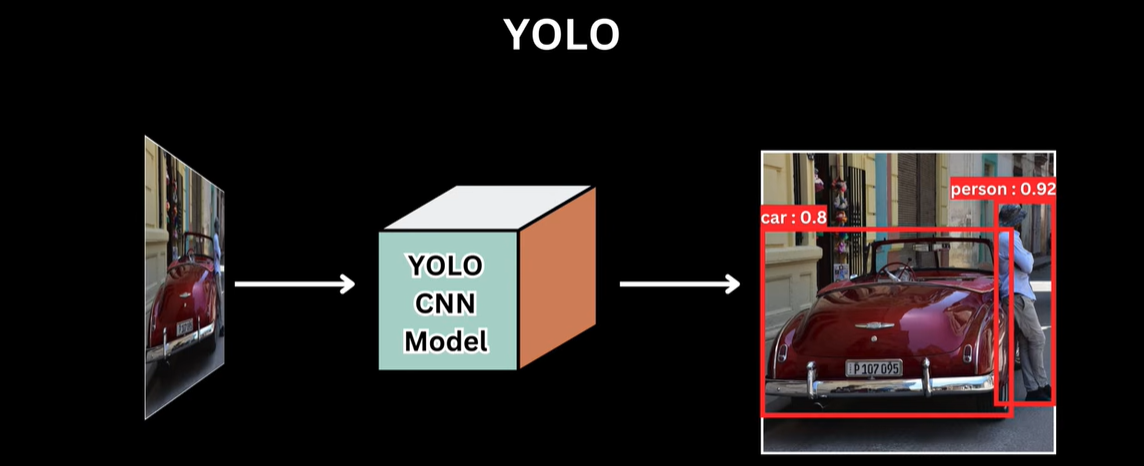

## Two-Stage vs One-Stage Detection

### Two-Stage Detectors

Examples:

* R-CNN
* Fast R-CNN
* Faster R-CNN

The process is approximately:

```text
Image
  ↓
Find candidate regions
  ↓
Classify candidate regions
  ↓
Predict/refine bounding boxes
  ↓
Final detections
```

The model separates the detection process into stages.

### One-Stage Detectors

YOLO belongs to the one-stage detector family.

The process is approximately:

```text
Image
  ↓
YOLO
  ↓
Predictions
  ↓
Final detections
```

The model directly predicts the objects, their locations, and their classes.

## How YOLO Works

At a high level, YOLO follows these steps:

```text
Input Image
     ↓
Preprocessing
     ↓
YOLO Neural Network
     ↓
Feature Extraction
     ↓
Object Predictions
     ↓
Confidence Filtering
     ↓
Non-Maximum Suppression
     ↓
Final Detections
```

Let's break this down.

### Step 1: Input Image

YOLO receives an image as input.

For example:

```text
Image
 ↓
Person + Car + Dog
```

The image is converted into a numerical representation that the neural network can process.

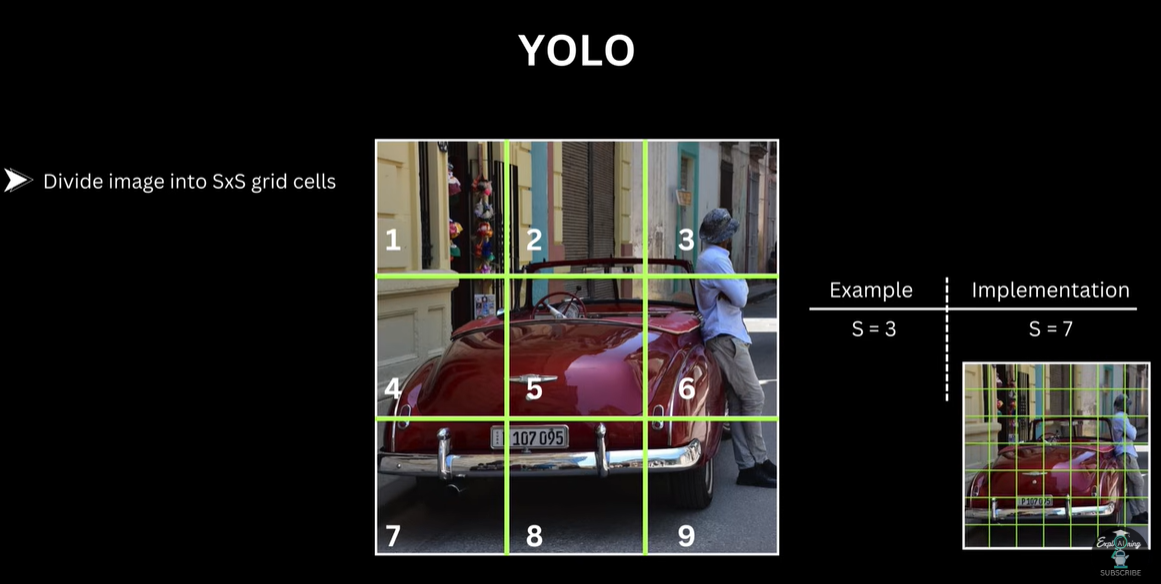

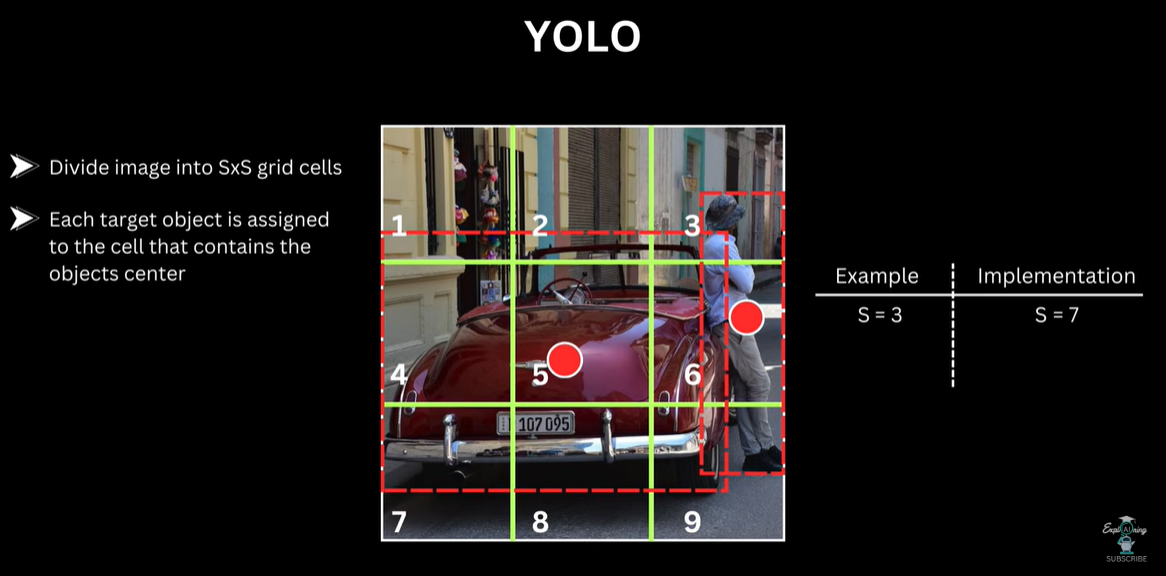

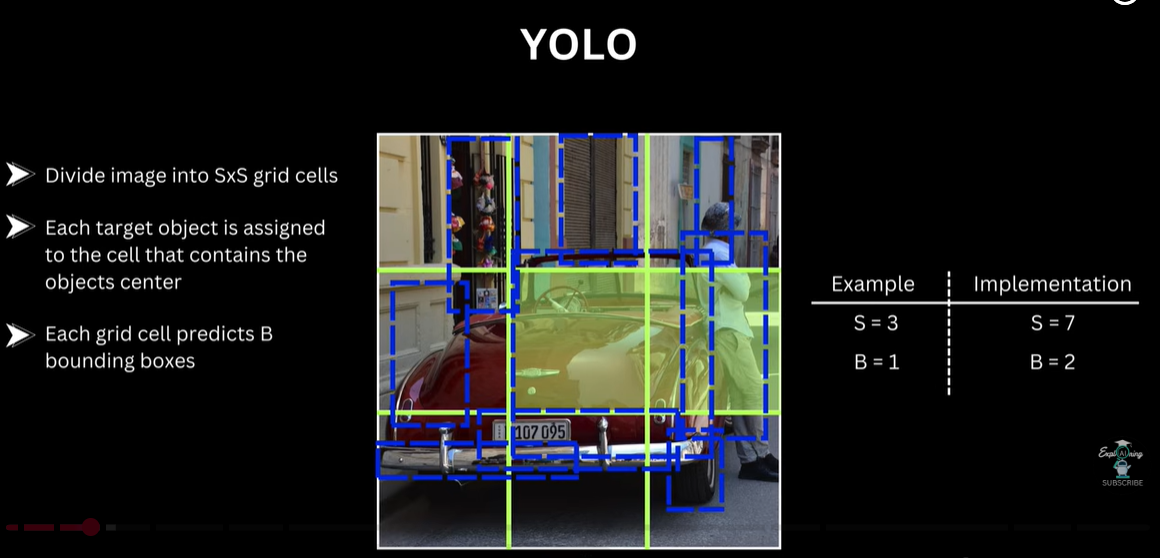

### Step 2: Feature Extraction

The image passes through the neural network.

The network learns useful visual features such as:

```text
Edges
 ↓
Textures
 ↓
Shapes
 ↓
Object parts
```

Deeper layers learn increasingly meaningful representations of the image.

Modern YOLO architectures typically contain components responsible for:

* Feature extraction
* Feature aggregation
* Object prediction

These are often described as the:

```text
Backbone → Neck → Detection Head
```

## YOLO Architecture

### Backbone

The **backbone** extracts visual features from the image.

```text
Image
  ↓
Backbone
  ↓
Feature Maps
```

It learns patterns such as edges, textures, shapes, and object features.

### Neck

The **neck** combines and processes features from different levels of the network.

This is important because objects can appear at different sizes.

For example:

```text
Small object
Medium object
Large object
```

The neck helps the model use information from different feature scales.

### Detection Head

The **detection head** produces the final predictions.

It predicts information such as:

* Bounding box
* Objectness/confidence
* Class

Conceptually:

```text
Feature Maps
     ↓
Detection Head
     ↓
┌────────────────────────┐
│ Bounding Box           │
│ Confidence             │
│ Class                  │
└────────────────────────┘
```

## Bounding Boxes

A bounding box tells us where an object is located.

It can be represented using:

```text
x
y
width
height
```

For example:

```text
Bounding Box = [x, y, width, height]
```

Depending on the YOLO implementation and format, coordinates may be represented differently, such as:

```text
x_center
y_center
width
height
```

Often these values are normalized between `0` and `1`.

## Confidence Score

YOLO also produces a confidence score indicating how confident the model is about a detection.

For example:

```text
Dog → 0.94
Car → 0.87
Person → 0.76
```

A higher score generally means the model has greater confidence in that prediction.

We can set a **confidence threshold**.

For example:

```text
Confidence threshold = 0.50
```

Predictions below the threshold may be discarded.

## Class Prediction

YOLO also predicts which class an object belongs to.

For example:

```text
Bounding Box
      ↓
┌───────────────┐
│      Dog      │
│   Confidence  │
│      0.94     │
└───────────────┘
```

For an image containing several objects:

```text
Person → 0.92
Car    → 0.89
Dog    → 0.94
```

## Non-Maximum Suppression

Sometimes the model predicts multiple overlapping bounding boxes for the same object.

For example:

```text
        ┌──────────────┐
        │              │
   ┌─────────────┐     │
   │     DOG     │     │
   └─────────────┘     │
        └──────────────┘
```

We don't want to return three detections for one dog.

YOLO therefore uses **Non-Maximum Suppression (NMS)** to remove redundant overlapping boxes.

The basic idea is:

1. Identify overlapping predictions.
2. Keep the prediction with the highest confidence.
3. Remove highly overlapping lower-confidence predictions.
4. Repeat for other objects.

## IoU and YOLO

IoU stands for:

> **Intersection over Union**

It measures how much two bounding boxes overlap.

```text
IoU = Area of Intersection / Area of Union
```

IoU ranges from:

```text
0 → No overlap
1 → Perfect overlap
```

IoU is important when evaluating whether a predicted bounding box sufficiently overlaps the ground-truth box.

